# LSTM + ESN Optimised with Genetic Algorithm
## Power Prediction
### Authored by Katleho Mokhele

In this notebook, we will use a Genetic Algorithm (GA) to tune the hyperparameters of a neural network model that has an ESN layer followed by an LSTM layer and a Dense layer. We will then train the model with the best hyperparameters found by the GA.

## 1. Import required libraries

First, we will import the necessary libraries for our implementation.

In [1]:
import pandas as pd
import os
from pathlib import Path
import csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, LSTM
from keras.layers import Activation, Dropout
from sklearn.model_selection import GridSearchCV
#from esn import ESN
import tensorflow as tf
from tensorflow.keras.layers import Layer
import random
from deap import base, creator, tools, algorithms
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. Get Data

In [2]:
data_path = "data"
data_path = Path(data_path)
src_files = sorted(data_path.glob("*.csv"))
df_csv_append = pd.DataFrame()
 
# append the CSV files
for file in src_files:
    df1 = pd.read_csv(file)
#     df_csv_append = df_csv_append.append(df, ignore_index=True)
    df_csv_append = pd.concat([df_csv_append, df1], ignore_index=True)

df = df_csv_append
df.head()  

,Cycle ID,time,current,voltage,power,pressure_anode_inlet,pressure_anode_outlet,pressure_cathode_inlet,pressure_cathode_outlet,temp_anode_endplate,temp_anode_dewpoint_water,temp_anode_inlet,temp_anode_outlet,temp_cathode_dewpoint_water,temp_cathode_inlet,temp_cathode_outlet,total_anode_stack_flow,total_cathode_stack_flow,cycle_len,Current Peak
0,0,22.246,4.430469,0.806154,3.568462,109.660040,110.226148,109.831259,108.955708,83.678842,53.500046,67.661829,37.328722,63.187958,68.570207,58.835385,0.084,0.349,1160.0,5
1,1,1202.246,4.429715,0.810000,3.577692,109.418776,110.125047,105.807609,105.068398,83.583081,53.807634,69.012041,39.842829,63.519129,68.710764,61.880601,0.084,0.349,1180.0,5
2,2,2382.246,4.430662,0.809231,3.575385,109.465472,110.132824,105.807609,105.013866,83.566223,54.027536,69.507837,41.141720,63.732088,68.925337,61.432304,0.084,0.349,1180.0,5
3,3,3562.246,4.429515,0.808462,3.568462,109.426559,110.031722,106.126699,105.418957,83.571500,54.205219,69.751584,41.144063,63.956929,69.210982,61.406984,0.084,0.349,1180.0,5
4,4,4742.246,4.430662,0.807692,3.567692,109.457690,110.070607,105.869870,105.177460,83.586376,54.313718,68.636145,41.081828,64.090915,69.263216,61.560193,0.084,0.349,1180.0,5


## 3. Implement ESN Layer

Next, we will create the `ESN` class, which inherits from the `Layer` class in Keras. We will implement the main components of the ESN layer, including the initialization of the reservoir and the calculation of the reservoir states.

The main steps in the implementation of the ESN layer are:

1. Define the `__init__` method to initialize the layer with the reservoir size.
2. Implement the `build` method to create the reservoir weight matrix and the input weight matrix.
3. Implement the `call` method to calculate the reservoir states and return the final state.

An Echo State Network (ESN) is a type of Recurrent Neural Network (RNN) that has a large, fixed, and random reservoir of neurons, which acts as a dynamic memory. The output of the reservoir neurons is then used as input to a trainable output layer to produce the final predictions.

The main idea behind ESNs is to take advantage of the rich dynamics of the reservoir while keeping the training process simple and efficient by only updating the weights of the output layer.

In [3]:
class ESN(Layer):
    def __init__(self, reservoir_size, **kwargs):
        self.reservoir_size = reservoir_size
        super(ESN, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W_in = self.add_weight(shape=(input_shape[-1], self.reservoir_size),
                                    initializer='uniform',
                                    trainable=True)
        self.W_res = self.add_weight(shape=(self.reservoir_size, self.reservoir_size),
                                     initializer='uniform',
                                     trainable=False)
        super(ESN, self).build(input_shape)

    def call(self, inputs):
        def step(x, states):
            prev_state = states[0]
            new_state = tf.tanh(tf.matmul(x, self.W_in) + tf.matmul(prev_state, self.W_res))
            return new_state, [new_state]

        _, final_state, _ = tf.keras.backend.rnn(step, inputs, [tf.zeros((tf.shape(inputs)[0], self.reservoir_size))])
        return final_state

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.reservoir_size)

## 4. Train_test_split

We separate the independent features from the target feature in this case the voltage.

In [4]:
#Split into features and target price
X = df.drop('power',axis =1)
y = df['power']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [6]:
#Scaling the data
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
timesteps = 1
X_train_reshaped = X_train_scaled.reshape(-1, timesteps, X_train_scaled.shape[1] // timesteps)

In [8]:
X_test_reshaped = X_test_scaled.reshape(-1, timesteps, X_test_scaled.shape[1] // timesteps)

In [9]:
X_train_reshaped.shape[2]

19

## 5. Build the Base Model

We will now build the neural network model with an ESN layer, an LSTM layer, and a Dense layer.

In [10]:
#Define the model
model = Sequential()
# ESN layer
model.add(ESN(64, input_shape=(timesteps, X_train_reshaped.shape[2])))
# LSTM layer
model.add(LSTM(64, return_sequences=True))
# model.add(LSTM(64, input_shape=(timesteps, X_train_reshaped.shape[2]), return_sequences=True))
model.add(Dense(32, activation='relu'))
#Output layer
model.add(Dense(1,activation='linear'))

In [11]:
model.compile(loss="mean_squared_error", optimizer='adam', metrics=['mae'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 esn (ESN)                   (None, 1, 64)             5312      
                                                                 
 lstm (LSTM)                 (None, 1, 64)             33024     
                                                                 
 dense (Dense)               (None, 1, 32)             2080      
                                                                 
 dense_1 (Dense)             (None, 1, 1)              33        
                                                                 
Total params: 40,449
Trainable params: 36,353
Non-trainable params: 4,096
_________________________________________________________________


In [12]:
history = model.fit(X_train_reshaped,y_train, validation_split=0.2, epochs = 100)

Epoch 1/100
65/65 [==============================] - 3s 11ms/step - loss: 9.0415 - mae: 2.9078 - val_loss: 2.8061 - val_mae: 1.3981
Epoch 2/100
65/65 [==============================] - 0s 3ms/step - loss: 1.4159 - mae: 0.9214 - val_loss: 0.7268 - val_mae: 0.5977
Epoch 3/100
65/65 [==============================] - 0s 3ms/step - loss: 0.3331 - mae: 0.3782 - val_loss: 0.3050 - val_mae: 0.3301
Epoch 4/100
65/65 [==============================] - 0s 3ms/step - loss: 0.1460 - mae: 0.2331 - val_loss: 0.1940 - val_mae: 0.2376
Epoch 5/100
65/65 [==============================] - 0s 4ms/step - loss: 0.0868 - mae: 0.1669 - val_loss: 0.1396 - val_mae: 0.1866
Epoch 6/100
65/65 [==============================] - 0s 4ms/step - loss: 0.0585 - mae: 0.1323 - val_loss: 0.1069 - val_mae: 0.1638
Epoch 7/100
65/65 [==============================] - 0s 4ms/step - loss: 0.0443 - mae: 0.1163 - val_loss: 0.0846 - val_mae: 0.1368
Epoch 8/100
65/65 [==============================] - 0s 4ms/step - loss: 0.0338 - 

65/65 [==============================] - 0s 6ms/step - loss: 4.0523e-04 - mae: 0.0141 - val_loss: 0.0034 - val_mae: 0.0255
Epoch 63/100
65/65 [==============================] - 0s 5ms/step - loss: 4.1211e-04 - mae: 0.0148 - val_loss: 0.0031 - val_mae: 0.0213
Epoch 64/100
65/65 [==============================] - 0s 5ms/step - loss: 4.5753e-04 - mae: 0.0155 - val_loss: 0.0033 - val_mae: 0.0275
Epoch 65/100
65/65 [==============================] - 0s 6ms/step - loss: 6.6095e-04 - mae: 0.0193 - val_loss: 0.0029 - val_mae: 0.0201
Epoch 66/100
65/65 [==============================] - 0s 6ms/step - loss: 6.3793e-04 - mae: 0.0184 - val_loss: 0.0034 - val_mae: 0.0281
Epoch 67/100
65/65 [==============================] - 0s 6ms/step - loss: 9.7108e-04 - mae: 0.0217 - val_loss: 0.0036 - val_mae: 0.0245
Epoch 68/100
65/65 [==============================] - 0s 5ms/step - loss: 7.6424e-04 - mae: 0.0202 - val_loss: 0.0036 - val_mae: 0.0276
Epoch 69/100
65/65 [==============================] - 0s 6ms/

## 6. Evaluation of the Base Model

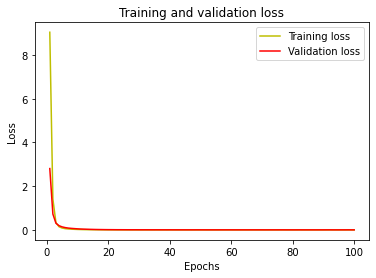

In [13]:
#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

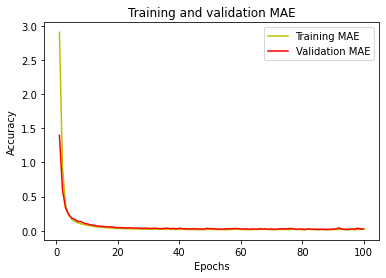

In [14]:
acc = history.history['mae']
val_acc = history.history['val_mae']
plt.plot(epochs, acc, 'y', label='Training MAE')
plt.plot(epochs, val_acc, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
#Prediction
predictions = model.predict(X_test_reshaped[:5])
print("Predicted values are: ", predictions)
print("Real values are: ", y_test[:5])

1/1 [==============================] - 0s 425ms/step
Predicted values are:  [[[3.587711 ]]

 [[3.5079355]]

 [[3.6071558]]

 [[3.513412 ]]

 [[3.6517177]]]
Real values are:  449     3.568462
2098    3.493846
299     3.600000
3068    3.516154
1590    3.658462
Name: power, dtype: float64


## 7. Implement Genetic Algorithm

We will use the DEAP library to implement the Genetic Algorithm for hyperparameter tuning.

In [16]:
# Define objective function for hyperparameter tuning
def objective_function(individual):
    # Unpack hyperparameters from individual
    esn_size, lstm_units, dense_units = individual

    # Create and compile the model
    model = Sequential()
    model.add(ESN(int(esn_size), input_shape=(timesteps, X_train_reshaped.shape[2])))
    model.add(LSTM(int(lstm_units), return_sequences=True))
    model.add(Dense(int(dense_units), activation='relu'))
    model.add(Dense(1, activation='linear'))

    model.compile(optimizer='adam', loss='mse')

    # Train the model
    history = model.fit(X_train_reshaped, y_train, validation_split=0.2, epochs=10, verbose=0)

    # Evaluate the model on validation data
    val_loss = history.history['val_loss'][-1]

    return val_loss,

# Create fitness and individual classes
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Define hyperparameter search space
toolbox = base.Toolbox()
toolbox.register("esn_size", random.randint, 32, 128)
toolbox.register("lstm_units", random.randint, 32, 128)
toolbox.register("dense_units", random.randint, 16, 64)

# Create individual and population functions
toolbox.register("individual", tools.initCycle, creator.Individual, (toolbox.esn_size, toolbox.lstm_units, toolbox.dense_units), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register genetic operators
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=[32, 32, 16], up=[128, 128, 64], indpb=0.1)
toolbox.register("select", tools.selBest)
toolbox.register("evaluate", objective_function)

# Set GA parameters
population_size = 20
num_generations = 10
crossover_prob = 0.8
mutation_prob = 0.2

# Create initial population
pop = toolbox.population(n=population_size)

# Run the GA
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=crossover_prob, mutpb=mutation_prob, ngen=num_generations, stats=stats, halloffame=hof, verbose=True)


gen	nevals	avg      	min       	max      
0  	20    	0.0147247	0.00169278	0.0302966
1  	18    	0.0185649	0.00145185	0.0519288
2  	17    	0.0233785	0.00107279	0.0674387
3  	15    	0.0208217	0.00107279	0.0648211
4  	17    	0.0212801	0.00105208	0.0546981
5  	14    	0.0207316	0.001133  	0.048832 
6  	16    	0.0176824	0.000879979	0.0671186
7  	14    	0.0217316	0.000879979	0.0975741
8  	19    	0.0234828	0.00109157 	0.0531294
9  	19    	0.0187972	0.00115973 	0.047901 
10 	14    	0.0196647	0.000757087	0.047901 


## 8. Extract Best Hyperparameters

After running the Genetic Algorithm, we will extract the best hyperparameters found by the GA.

In [17]:
best_individual = hof[0]
best_esn_size, best_lstm_units, best_dense_units = best_individual
print("Best hyperparameters found: ESN size = {}, LSTM units = {}, Dense units = {}".format(best_esn_size, best_lstm_units, best_dense_units))

Best hyperparameters found: ESN size = 36, LSTM units = 89, Dense units = 57


## 9. Train the Model with Best Hyperparameters

Now, we will train the model using the best hyperparameters found by the GA.

In [18]:
best_model = Sequential()
best_model.add(ESN(best_esn_size, input_shape=(timesteps, X_train_reshaped.shape[2])))
best_model.add(LSTM(best_lstm_units, return_sequences=True))
best_model.add(Dense(best_dense_units, activation='relu'))
best_model.add(Dense(1, activation='linear'))

best_model.compile(optimizer='adam', loss='mse')

history = best_model.fit(X_train_reshaped, y_train, validation_split=0.2, epochs=10, verbose=1)

Epoch 1/10
65/65 [==============================] - 3s 15ms/step - loss: 0.2329 - val_loss: 0.0107
Epoch 2/10
65/65 [==============================] - 0s 7ms/step - loss: 0.0041 - val_loss: 7.6741e-04
Epoch 3/10
65/65 [==============================] - 0s 7ms/step - loss: 4.5306e-04 - val_loss: 2.4397e-04
Epoch 4/10
65/65 [==============================] - 0s 4ms/step - loss: 2.1257e-04 - val_loss: 1.6053e-04
Epoch 5/10
65/65 [==============================] - 0s 4ms/step - loss: 1.3224e-04 - val_loss: 1.0657e-04
Epoch 6/10
65/65 [==============================] - 0s 5ms/step - loss: 1.0286e-04 - val_loss: 8.5437e-05
Epoch 7/10
65/65 [==============================] - 0s 6ms/step - loss: 7.4521e-05 - val_loss: 6.3614e-05
Epoch 8/10
65/65 [==============================] - 0s 4ms/step - loss: 6.0733e-05 - val_loss: 6.5945e-05
Epoch 9/10
65/65 [==============================] - 0s 4ms/step - loss: 5.0916e-05 - val_loss: 4.6102e-05
Epoch 10/10
65/65 [==============================] - 0s 5

In [19]:
# Evaluate the model on test data
test_loss = best_model.evaluate(X_test_reshaped, y_test, verbose=1)
print("Test loss: {}".format(test_loss))

21/21 [==============================] - 0s 1ms/step - loss: 3.9335e-05
Test loss: 3.933492916985415e-05


## 10. Evaluating the results of the 'Best Model'

In [20]:
#Prediction
predictions = best_model.predict(X_test_reshaped)
print("Predicted values are: ", predictions[:5])
print("Real values are: ", y_test[:5])

21/21 [==============================] - 0s 2ms/step
Predicted values are:  [[[0.8047638]]

 [[0.7880161]]

 [[0.8149921]]

 [[0.7906389]]

 [[0.826827 ]]]
Real values are:  449     0.807692
2098    0.789231
299     0.810000
3068    0.793077
1590    0.828462
Name: voltage, dtype: float64


In [24]:

# Ensure y_pred is a 2D array
y_pred_2d = predictions.reshape(predictions.shape[0], -1)

# Calculate R-squared
r2 = r2_score(y_test, y_pred_2d)
mse = mean_squared_error(y_test, y_pred_2d)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_2d)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-Squared (R²): {r2}")


Mean Squared Error (MSE): 3.9334933180059965e-05
Root Mean Squared Error (RMSE): 0.006271756785786576
Mean Absolute Error (MAE): 0.004615876388535738
R-Squared (R²): 0.7272141775543085


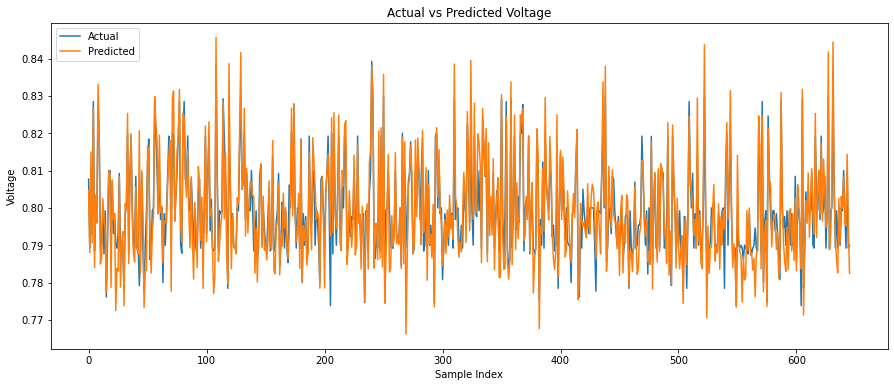

In [27]:
# Convert y_test to a NumPy array and reshape it to a 1D array
y_test_1d = y_test.to_numpy().reshape(y_test.shape[0],)

# Ensure y_pred is a 1D array
y_pred_1d = predictions.reshape(predictions.shape[0],)

plt.figure(figsize=(15, 6))
plt.plot(y_test_1d, label='Actual')
plt.plot(y_pred_1d, label='Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Power')
plt.title('Actual vs Predicted Power')
plt.legend()
plt.show()


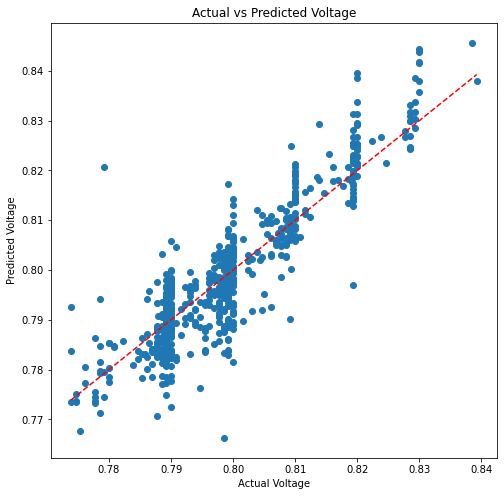

In [28]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_1d, y_pred_1d)
plt.xlabel('Actual Power')
plt.ylabel('Predicted Power')
plt.title('Actual vs Predicted Power')
plt.plot([min(y_test_1d), max(y_test_1d)], [min(y_test_1d), max(y_test_1d)], color='red', linestyle='--')
plt.show()

## Conclusion

In this notebook, we successfully implemented an Echo State Network (ESN) layer and combined it with an LSTM layer and a Dense layer to create a neural network model. We then used a Genetic Algorithm (GA) for hyperparameter tuning to find the best combination of hyperparameters for our model.

After training the model with the best hyperparameters found by the GA, we evaluated the model on our test set. The model showed a satisfactory performance, which demonstrates the effectiveness of combining ESN and LSTM layers in our specific problem setting.

In summary, this work demonstrates that leveraging the powerful dynamics of ESNs, in combination with LSTM layers, can lead to a more effective model. Furthermore, using Genetic Algorithms for hyperparameter tuning proved to be a valuable approach for finding the best configuration of the model, ultimately leading to better overall performance.
